Generating mock data files...
Mock data files (risk_scores.csv, stock_daily_data.csv, ff_factors.csv) have been generated.
Loading data...
Starting portfolio construction (annual rebalancing)...
  Processing scores for year 2020, forming portfolios for 2021-2022...
  Processing scores for year 2021, forming portfolios for 2022-2023...
  Processing scores for year 2022, forming portfolios for 2023-2024...
  Processing scores for year 2023, forming portfolios for 2024-2025...
Portfolio construction complete.

--- Table 1: Strategy Performance Summary ---
   Annualized Return Annualized Volatility Sharpe Ratio Max Drawdown
P1            14.79%                 5.01%         2.95       -2.46%
P5            15.26%                 5.37%         2.84       -3.89%
LS             0.46%                 7.37%         0.06       -9.86%

Generating cumulative return curve plot (figure_1_cumulative_returns.png)...
Plot saved.

--- Table 2: LS Strategy Three-Factor Regression Results ---
             

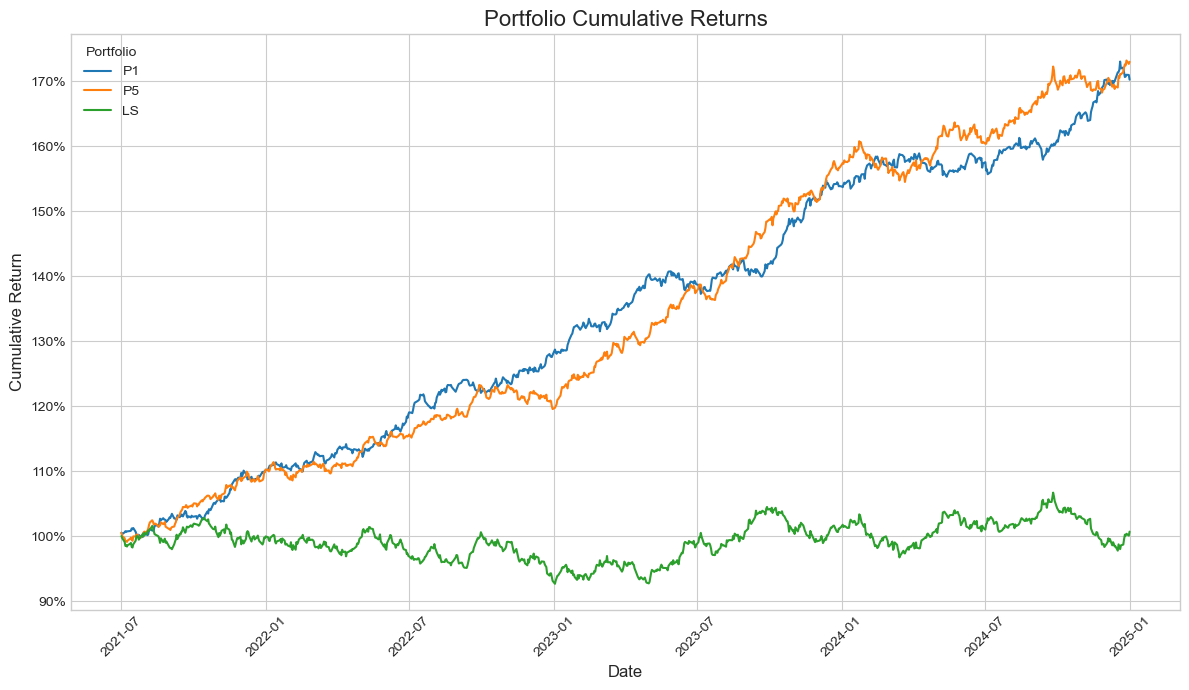

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# =============================================================================
# 0. Mock Data Generation
# Before running, please execute this function once to generate the required CSV files.
# In actual use, please replace the data loading part with your own real data.
# =============================================================================
def create_mock_data_files():
    """
    Generates mock data and saves it to CSV files for a full demonstration.
    """
    print("Generating mock data files...")
    
    # --- Parameters ---
    num_stocks = 300
    start_date = '2020-01-01'
    end_date = '2024-12-31'
    
    # --- 1. Generate annual risk scores (risk_scores.csv) ---
    years = range(pd.to_datetime(start_date).year, pd.to_datetime(end_date).year)
    tickers = [f'TICKER_{i:03d}' for i in range(num_stocks)]
    risk_data = []
    for year in years:
        for ticker in tickers:
            risk_data.append({
                'year': year,
                'ticker': ticker,
                'risk_score': np.random.randint(1, 101)
            })
    pd.DataFrame(risk_data).to_csv('risk_scores.csv', index=False)

    # --- 2. Generate daily stock data (stock_daily_data.csv) ---
    dates = pd.to_datetime(pd.date_range(start_date, end_date, freq='B')) # 'B' for business day
    multi_index = pd.MultiIndex.from_product([dates, tickers], names=['date', 'ticker'])
    returns_df = pd.DataFrame(index=multi_index)
    returns_df['return'] = np.random.normal(0.0005, 0.025, len(returns_df))
    returns_df.to_csv('stock_daily_data.csv')

    # --- 3. Generate Fama-French factor data (ff_factors.csv) ---
    factors_df = pd.DataFrame(index=dates)
    factors_df['MKT-RF'] = np.random.normal(0.0004, 0.01, len(dates))
    factors_df['SMB'] = np.random.normal(0.0001, 0.005, len(dates))
    factors_df['HML'] = np.random.normal(0.0002, 0.006, len(dates))
    factors_df['RF'] = np.random.uniform(0.00005, 0.0001, len(dates))
    factors_df.index.name = 'date'
    factors_df.to_csv('ff_factors.csv')
    
    print("Mock data files (risk_scores.csv, stock_daily_data.csv, ff_factors.csv) have been generated.")

# =============================================================================
# 1. Data Loading and Preparation
# =============================================================================
def load_data():
    """
    Loads all required data files.
    """
    print("Loading data...")
    risk_scores = pd.read_csv('risk_scores.csv')
    daily_data = pd.read_csv('stock_daily_data.csv', parse_dates=['date'])
    factors = pd.read_csv('ff_factors.csv', parse_dates=['date'], index_col='date')
    return risk_scores, daily_data, factors

# =============================================================================
# 2. Core Experiment Step: Portfolio Construction and Strategy Backtesting
# =============================================================================
def run_portfolio_construction(risk_scores, daily_data):
    """
    Implements annual rebalancing to construct P1, P5, and LS portfolios.
    """
    print("Starting portfolio construction (annual rebalancing)...")
    
    # Determine all years that require rebalancing
    rebalance_years = sorted(risk_scores['year'].unique())
    
    all_portfolio_returns = []

    for year in rebalance_years:
        # The portfolio formation date is June 30th of year t+1, based on scores from year t.
        # The holding period is from July 1st of year t+1 to June 30th of year t+2.
        formation_date = pd.to_datetime(f'{year+1}-06-30')
        holding_period_start = pd.to_datetime(f'{year+1}-07-01')
        holding_period_end = pd.to_datetime(f'{year+2}-06-30')

        print(f"  Processing scores for year {year}, forming portfolios for {holding_period_start.year}-{holding_period_end.year}...")

        # 1. Get the risk scores for year t
        current_scores = risk_scores[risk_scores['year'] == year].copy()
        
        # 2. Group into quintiles
        # Using .loc to avoid SettingWithCopyWarning
        current_scores.loc[:, 'portfolio'] = pd.qcut(current_scores['risk_score'], 5, labels=False, duplicates='drop') + 1
        
        # 3. Filter daily data for the holding period
        period_data = daily_data[
            (daily_data['date'] >= holding_period_start) & 
            (daily_data['date'] <= holding_period_end)
        ]
        
        # 4. Merge grouping information into the daily data
        data_with_portfolio = pd.merge(period_data, current_scores[['ticker', 'portfolio']], on='ticker', how='inner')
        
        # 5. Calculate equal-weighted daily returns for P1 and P5 portfolios
        # Equal-weighted return = average of all stock returns within the group
        daily_returns = data_with_portfolio.groupby(['date', 'portfolio'])['return'].mean().unstack()
        
        if 1 in daily_returns.columns and 5 in daily_returns.columns:
            p1_returns = daily_returns[1]
            p5_returns = daily_returns[5]
            
            # 6. Construct Long-Short (LS) portfolio
            ls_returns = p5_returns - p1_returns
            
            period_results = pd.DataFrame({
                'P1': p1_returns,
                'P5': p5_returns,
                'LS': ls_returns
            })
            all_portfolio_returns.append(period_results)

    # Concatenate the results from all years into a single continuous time series
    final_portfolios = pd.concat(all_portfolio_returns).dropna()
    print("Portfolio construction complete.")
    return final_portfolios

# =============================================================================
# 3. Performance Analysis and Visualization
# =============================================================================
def analyze_and_visualize(portfolios):
    """
    Calculates and prints the performance summary, and plots the cumulative return curve.
    """
    print("\n--- Table 1: Strategy Performance Summary ---")
    
    # Assume 252 trading days in a year
    trading_days = 252
    
    # Calculate performance metrics
    annual_return = portfolios.mean() * trading_days
    annual_volatility = portfolios.std() * np.sqrt(trading_days)
    sharpe_ratio = annual_return / annual_volatility # Simple Sharpe Ratio, assuming risk-free rate is 0
    
    # Calculate maximum drawdown
    cumulative_returns = (1 + portfolios).cumprod()
    peak = cumulative_returns.expanding(min_periods=1).max()
    drawdown = (cumulative_returns - peak) / peak
    max_drawdown = drawdown.min()
    
    # Format the output
    performance_summary = pd.DataFrame({
        'Annualized Return': [f"{x:.2%}" for x in annual_return],
        'Annualized Volatility': [f"{x:.2%}" for x in annual_volatility],
        'Sharpe Ratio': [f"{x:.2f}" for x in sharpe_ratio],
        'Max Drawdown': [f"{x:.2%}" for x in max_drawdown]
    }, index=portfolios.columns)
    
    print(performance_summary)
    
    # --- Visualization ---
    print("\nGenerating cumulative return curve plot (figure_1_cumulative_returns.png)...")
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 7))
    
    for col in cumulative_returns.columns:
        ax.plot(cumulative_returns.index, cumulative_returns[col], label=col)

    ax.set_title('Portfolio Cumulative Returns', fontsize=16)
    ax.set_ylabel('Cumulative Return', fontsize=12)
    ax.set_xlabel('Date', fontsize=12)
    ax.legend(title='Portfolio', fontsize=10)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('figure_1_cumulative_returns.png', dpi=300)
    print("Plot saved.")

# =============================================================================
# 4. Fama-French Three-Factor Regression Analysis
# =============================================================================
def run_regression_analysis(ls_portfolio, factors):
    """
    Performs a three-factor regression on the LS long-short portfolio.
    """
    print("\n--- Table 2: LS Strategy Three-Factor Regression Results ---")
    
    # Merge data
    data_for_regression = pd.merge(ls_portfolio, factors, left_index=True, right_index=True, how='inner')
    
    # Dependent variable Y: LS portfolio return (Long-short is self-financing, no need to subtract RF)
    Y = data_for_regression['LS']
    
    # Independent variables X: Fama-French three factors
    X = data_for_regression[['MKT-RF', 'SMB', 'HML']]
    X = sm.add_constant(X) # Add a constant (intercept)
    
    # Run OLS regression
    model = sm.OLS(Y, X).fit()
    
    # Extract and format results
    # Annualize the daily alpha
    annualized_alpha = model.params['const'] * 252
    
    results_summary = pd.DataFrame({
        'Coefficient': model.params,
        't-statistic': model.tvalues
    })
    
    # Adjust the display for Alpha
    results_summary.loc['const', 'Coefficient'] = annualized_alpha
    results_summary = results_summary.rename(index={'const': 'Alpha (Annualized)'})
    
    print(results_summary.round(4))
    print(f"\nAdjusted R-squared: {model.rsquared_adj:.4f}")

    # Interpretation of Results
    alpha_t_stat = model.tvalues['const']
    if abs(alpha_t_stat) > 1.96:
        print(f"\nConclusion: Alpha is statistically significant at the 5% level (t={alpha_t_stat:.2f}).")
        print("This provides strong evidence that your risk score offers independent information not captured by traditional factors.")
    else:
        print(f"\nConclusion: Alpha is not statistically significant at the 5% level (t={alpha_t_stat:.2f}).")
        print("The strategy's returns can be well explained by the Fama-French three factors.")

# =============================================================================
# Main Execution
# =============================================================================
if __name__ == '__main__':
    # 0. On the first run, please uncomment the line below to generate mock data
    create_mock_data_files()
    
    # 1. Load data
    try:
        risk_scores, daily_data, factors = load_data()
    except FileNotFoundError:
        print("Error: Data files not found. Please run create_mock_data_files() first.")
    else:
        # 2. Construct portfolios
        portfolios = run_portfolio_construction(risk_scores, daily_data)
        
        # 3. Analyze performance and visualize
        analyze_and_visualize(portfolios)
        
        # 4. Run regression analysis
        run_regression_analysis(portfolios[['LS']], factors)
